# SFR Overnight Momentum Backtest

Tests whether short-end SOFR futures overnight momentum persists into the next morning.

**Strategy:** Observe rate change during momentum window (default 18:00→22:00 NYC).
Enter at signal time, unwind next morning. All parameters in `CONFIG`.

In [7]:
%load_ext autoreload
%autoreload 2

import datetime, sys
import numpy as np
import pandas as pd
import pytz
import matplotlib.pyplot as plt

sys.path.append("../../")

from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

NYC = pytz.timezone("America/New_York")
CHI = pytz.timezone("America/Chicago")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
CONFIG = {
    # -- Data --
    "curve": "USD-SOFR-1D-Q12STIRT",
    "source": "BARCHART_STIRF-RL",
    "tenor": "IMM_1xIMM_2",        # SFR1 (front quarterly)
    "data_freq": "1h",              # must capture snapshot times

    # -- Period --
    "start": "2026-01-04",
    "end": "2026-05-20",

    # -- Momentum Window (NYC) --
    "session_open_hour": 18,        # session open / window start
    "session_open_min": 0,
    "signal_hour": 22,              # window end / trade entry
    "signal_min": 0,
    "unwind_hour": 8,               # trade exit (next morning)
    "unwind_min": 0,

    # -- Signal --
    # "raw"       - trade on any move
    # "threshold" - only if |move| >= min_move_bps
    # "zscore"    - only if |z-scored move| >= zscore_entry
    "momentum_metric": "raw",
    "min_move_bps": 0.0,
    "zscore_window": 20,
    "zscore_entry": 1.0,

    # -- Direction --
    # -1 = momentum: rate UP -> pay (profit if trend continues)
    # +1 = fade:     rate UP -> receive (profit if trend reverses)
    "trade_direction": -1,

    # -- Roll filter --
    # Exclude sessions within N bdays of IMM dates (3rd Wed of Mar/Jun/Sep/Dec)
    # to avoid constant-maturity roll artifacts. 0 to disable.
    "roll_exclusion_days": 1,

    # -- Risk --
    "trade_bpv": 100_000.0,         # $/bp per trade
    "tc_bps": 0.0,                  # round-trip transaction cost (bps)
}

In [ ]:
curve_mdp = IRSwapsMDP(source=CONFIG["source"])
ts_builder = TimeseriesBuilder()

start_dt = NYC.localize(datetime.datetime.strptime(CONFIG["start"], "%Y-%m-%d").replace(
    hour=CONFIG["session_open_hour"], minute=CONFIG["session_open_min"]))
end_dt = NYC.localize(datetime.datetime.strptime(CONFIG["end"], "%Y-%m-%d").replace(hour=17, minute=0))

q = UnifiedQuery(curve=CONFIG["curve"], tenor=CONFIG["tenor"], value=UnifiedValue.IRS_RATE)
intraday_df = ts_builder.get_timeseries(
    start=start_dt, end=end_dt, queries=[q], freq=CONFIG["data_freq"],
    mdps={"IRS": curve_mdp}, ignore_cache_miss=True,
)
rate_series = pd.to_numeric(intraday_df.sort_index().iloc[:, 0], errors="coerce").dropna()
rate_series.name = CONFIG["tenor"]
print(f"Fetched {len(rate_series):,} bars: {rate_series.index[0]} -> {rate_series.index[-1]}")
rate_series.tail()

In [4]:
def _session_date(ts):
    chi = ts.astimezone(CHI)
    return (chi + pd.Timedelta(days=1)).date() if chi.hour >= 17 else chi.date()


def build_backtest(rates, cfg):
    idx = pd.DatetimeIndex(rates.index)
    df = pd.DataFrame({
        "rate": rates.values,
        "session": idx.map(_session_date),
        "h": idx.map(lambda t: t.astimezone(NYC).hour),
        "m": idx.map(lambda t: t.astimezone(NYC).minute),
    }, index=idx)

    oh, om = cfg["session_open_hour"], cfg["session_open_min"]
    sh, sm = cfg["signal_hour"], cfg["signal_min"]
    uh, um = cfg["unwind_hour"], cfg["unwind_min"]

    rows = []
    for sd, g in df.groupby("session"):
        o = g[(g["h"] == oh) & (g["m"] == om)]
        s = g[(g["h"] == sh) & (g["m"] == sm)]
        u = g[(g["h"] == uh) & (g["m"] == um)]
        if o.empty or s.empty or u.empty:
            continue
        rows.append({
            "session_date": sd,
            "open_time": o.index[0], "open_rate": float(o["rate"].iloc[0]),
            "signal_time": s.index[0], "signal_rate": float(s["rate"].iloc[0]),
            "unwind_time": u.index[0], "unwind_rate": float(u["rate"].iloc[0]),
        })

    snap = pd.DataFrame(rows).set_index("session_date")
    snap.index = pd.DatetimeIndex(snap.index)

    move = snap["signal_rate"] - snap["open_rate"]
    move_bps = move * 100.0
    metric, d = cfg["momentum_metric"], cfg["trade_direction"]

    if metric == "raw":
        sig = np.sign(move) * d
    elif metric == "threshold":
        sig = pd.Series(
            np.where(move_bps.abs() >= cfg["min_move_bps"], np.sign(move) * d, 0.0),
            index=snap.index,
        )
    elif metric == "zscore":
        w = cfg["zscore_window"]
        z = (move - move.rolling(w, min_periods=max(2, w // 2)).mean()) / \
            move.rolling(w, min_periods=max(2, w // 2)).std()
        sig = pd.Series(
            np.where(z.abs() >= cfg["zscore_entry"], np.sign(z) * d, 0.0),
            index=snap.index,
        )
        snap["zscore"] = z
    else:
        raise ValueError(f"Unknown metric: {metric!r}")

    snap["signal"] = pd.Series(sig, index=snap.index, dtype=float).fillna(0.0)

    # IMM roll exclusion: zero out signals near quarterly roll dates
    excl_days = cfg.get("roll_exclusion_days", 0)
    if excl_days > 0:
        all_3rd_wed = pd.date_range(
            snap.index.min() - pd.Timedelta(days=60),
            snap.index.max() + pd.Timedelta(days=60),
            freq="WOM-3WED",
        )
        imm_dates = all_3rd_wed[all_3rd_wed.month.isin([3, 6, 9, 12])]
        excluded = set()
        for imm in imm_dates:
            for offset in range(-excl_days, excl_days + 1):
                excluded.add((imm + pd.offsets.BDay(offset)).normalize())
        roll_mask = snap.index.normalize().isin(excluded)
        n_excluded = int(roll_mask.sum())
        snap.loc[roll_mask, "signal"] = 0.0
        if n_excluded:
            print(f"IMM roll filter: excluded {n_excluded} sessions near "
                  f"{list(imm_dates.strftime('%Y-%m-%d'))}")

    snap["overnight_move_bps"] = move_bps
    snap["hold_move_bps"] = (snap["unwind_rate"] - snap["signal_rate"]) * 100.0

    bpv = float(cfg["trade_bpv"])
    snap["gross_pnl"] = -snap["signal"] * (snap["unwind_rate"] - snap["signal_rate"]) * bpv * 100.0
    snap["tc_cost"] = snap["signal"].abs() * float(cfg["tc_bps"]) * bpv * 2.0
    snap["net_pnl"] = snap["gross_pnl"] - snap["tc_cost"]
    snap["cum_pnl"] = snap["net_pnl"].cumsum()
    return snap


snap = build_backtest(rate_series, CONFIG)
active = snap[snap["signal"] != 0]
print(f"{len(snap)} sessions, {len(active)} trades "
      f"({(active['signal'] == -1).sum()} pay / {(active['signal'] == 1).sum()} receive)")

93 sessions, 93 trades (54 pay / 39 receive)


In [5]:
std = float(snap["net_pnl"].std())
sharpe = float(snap["net_pnl"].mean()) / std * np.sqrt(252) if std > 0 else 0.0
dd = snap["cum_pnl"] - snap["cum_pnl"].cummax()
win_pnl = float(active.loc[active["net_pnl"] > 0, "net_pnl"].sum()) if len(active) else 0.0
loss_pnl = float(active.loc[active["net_pnl"] <= 0, "net_pnl"].sum()) if len(active) else 0.0

dir_label = "Momentum" if CONFIG["trade_direction"] == -1 else "Fade"
print(f"\n{'='*60}")
print(f"  {CONFIG['tenor']} Overnight {dir_label}")
print(f"  {CONFIG['start']} -> {CONFIG['end']}")
print(f"  {CONFIG['session_open_hour']:02d}:{CONFIG['session_open_min']:02d} -> "
      f"{CONFIG['signal_hour']:02d}:{CONFIG['signal_min']:02d} -> "
      f"{CONFIG['unwind_hour']:02d}:{CONFIG['unwind_min']:02d} NYC")
print(f"{'='*60}")
print(f"  Trades:        {len(active):>6}  ({(active['signal']==-1).sum()} pay / "
      f"{(active['signal']==1).sum()} rcv)")
print(f"  Total PnL:     ${snap['net_pnl'].sum():>12,.0f}")
if len(active):
    print(f"  Win Rate:      {(active['net_pnl']>0).mean():.1%}")
    pf = win_pnl / abs(loss_pnl) if loss_pnl else float('inf')
    print(f"  Profit Factor: {pf:.2f}")
    print(f"  Avg Trade:     ${active['net_pnl'].mean():>12,.0f}")
    print(f"  Best Trade:    ${active['net_pnl'].max():>12,.0f}")
    print(f"  Worst Trade:   ${active['net_pnl'].min():>12,.0f}")
print(f"  Max Drawdown:  ${dd.min():>12,.0f}")
print(f"  Sharpe (ann):  {sharpe:>12.2f}")
print(f"{'='*60}")


  IMM_1xIMM_2 Overnight Momentum
  2026-01-04 -> 2026-05-20
  18:00 -> 22:00 -> 08:00 NYC
  Trades:            93  (54 pay / 39 rcv)
  Total PnL:     $     900,582
  Win Rate:      51.6%
  Profit Factor: 1.42
  Avg Trade:     $       9,684
  Best Trade:    $     784,587
  Worst Trade:   $    -214,685
  Max Drawdown:  $    -528,724
  Sharpe (ann):          1.44


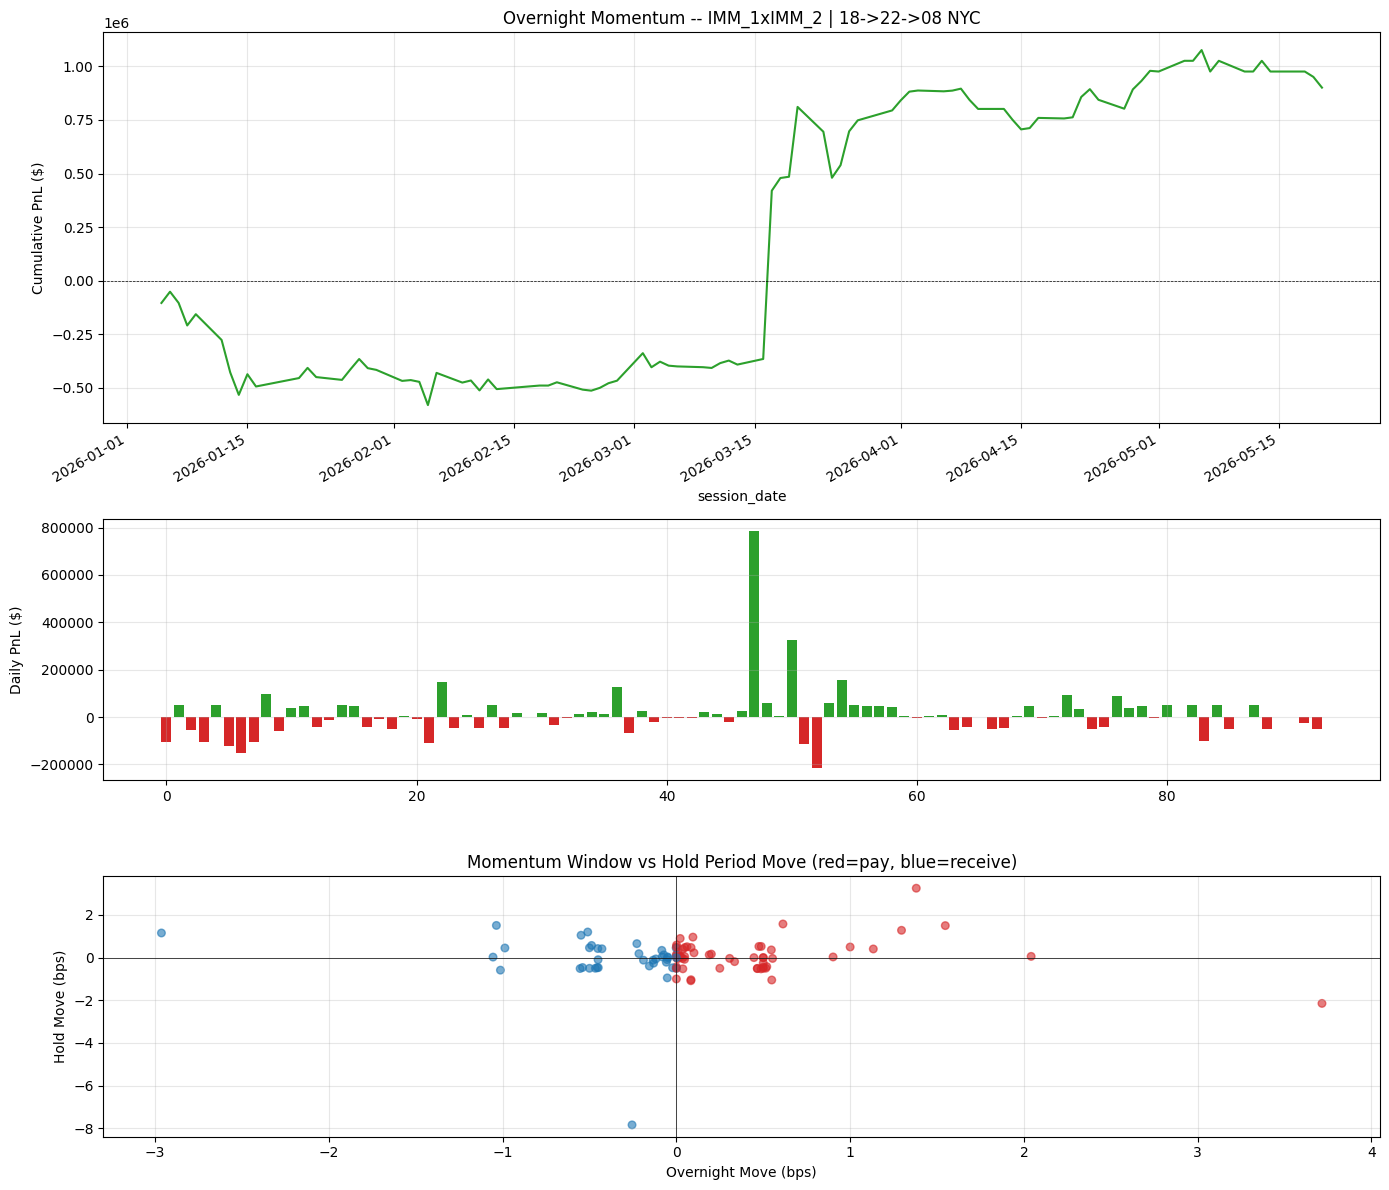

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={"height_ratios": [3, 2, 2]})

snap["cum_pnl"].plot(ax=axes[0], color="tab:green", lw=1.5)
axes[0].axhline(0, color="k", lw=0.5, ls="--")
dir_label = "Momentum" if CONFIG["trade_direction"] == -1 else "Fade"
axes[0].set_title(f"Overnight {dir_label} -- {CONFIG['tenor']} | "
                   f"{CONFIG['session_open_hour']:02d}->{CONFIG['signal_hour']:02d}->{CONFIG['unwind_hour']:02d} NYC")
axes[0].set_ylabel("Cumulative PnL ($)")
axes[0].grid(alpha=0.3)

colors = ["tab:green" if x > 0 else "tab:red" for x in snap["net_pnl"]]
axes[1].bar(range(len(snap)), snap["net_pnl"].values, color=colors, width=0.8)
axes[1].set_ylabel("Daily PnL ($)")
axes[1].grid(alpha=0.3)

c = snap["signal"].map({-1.0: "tab:red", 1.0: "tab:blue", 0.0: "gray"})
axes[2].scatter(snap["overnight_move_bps"], snap["hold_move_bps"], c=c, alpha=0.6, s=30)
axes[2].axhline(0, color="k", lw=0.5)
axes[2].axvline(0, color="k", lw=0.5)
axes[2].set_xlabel("Overnight Move (bps)")
axes[2].set_ylabel("Hold Move (bps)")
axes[2].set_title("Momentum Window vs Hold Period Move (red=pay, blue=receive)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Intraday Overnight Seasonality

Minute-by-minute cumulative rate change from session open across all sessions.
Shows the typical overnight drift pattern and dispersion.

In [7]:
import plotly.graph_objects as go

q_1min = UnifiedQuery(curve=CONFIG["curve"], tenor=CONFIG["tenor"], value=UnifiedValue.IRS_RATE)
df_1min = ts_builder.get_timeseries(
    start=start_dt, end=end_dt, queries=[q_1min], freq="1min",
    mdps={"IRS": curve_mdp}, ignore_cache_miss=True,
)
rate_1min = pd.to_numeric(df_1min.sort_index().iloc[:, 0], errors="coerce").dropna()
rate_1min.name = CONFIG["tenor"]
print(f"Fetched {len(rate_1min):,} 1-min bars")


READING USD-SOFR-1D-Q12STIRT computed cache...:   0%|          | 0/1 [00:00<?, ?it/s]


READING USD-SOFR-1D-Q12STIRT computed cache...: 100%|██████████| 1/1 [00:00<00:00,  1.03it/s]


READING USD-SOFR-1D-Q12STIRT curve analytics...:   0%|          | 0/1381 [00:00<?, ?it/s]


READING USD-SOFR-1D-Q12STIRT curve analytics...: 100%|██████████| 1381/1381 [00:00<00:00, 3249.05it/s]


LOADING USD-SOFR-1D-Q12STIRT raw curves...:   0%|          | 0/1380 [00:00<?, ?it/s]

...


PRICING USD-SOFR-1D-Q12STIRT IRSWAPS [curve-store, workers=8]...:  96%|█████████▋| 1064/1104 [00:06<00:00, 180.93it/s]


PRICING USD-SOFR-1D-Q12STIRT IRSWAPS [curve-store, workers=8]...:  98%|█████████▊| 1083/1104 [00:06<00:00, 179.62it/s]


WRITING USD-SOFR-1D-Q12STIRT computed cache...:   0%|          | 0/1104 [00:00<?, ?it/s]


WRITING USD-SOFR-1D-Q12STIRT computed cache...: 100%|██████████| 1104/1104 [00:07<00:00, 150.56it/s]

Fetched 130,352 1-min bars


In [8]:
oh, om = CONFIG["session_open_hour"], CONFIG["session_open_min"]
uh, um = CONFIG["unwind_hour"], CONFIG["unwind_min"]
unwind_offset = ((uh - oh) * 60 + (um - om)) % (24 * 60)

idx_1min = pd.DatetimeIndex(rate_1min.index)
sessions_1min = idx_1min.map(_session_date)
df_1min_tagged = pd.DataFrame({
    "rate": rate_1min.values, "session": sessions_1min,
}, index=idx_1min)

session_curves = {}
for sd, g in df_1min_tagged.groupby("session"):
    g = g.sort_index()
    nyc_times = g.index.tz_convert(NYC)
    hours = nyc_times.hour
    minutes = nyc_times.minute

    open_mask = (hours == oh) & (minutes == om)
    if not open_mask.any():
        continue
    open_rate = float(g.loc[open_mask, "rate"].iloc[0])

    mins_from_open = pd.Series(0, index=g.index, dtype=int)
    for i, ts in enumerate(nyc_times):
        h, m = ts.hour, ts.minute
        offset = ((h - oh) * 60 + (m - om)) % (24 * 60)
        mins_from_open.iloc[i] = offset

    mask = mins_from_open <= unwind_offset
    g_window = g[mask.values].copy()
    mfo = mins_from_open[mask.values]
    cum_bps = (g_window["rate"] - open_rate) * 100.0
    curve = pd.Series(cum_bps.values, index=mfo.values, dtype=float)
    curve = curve[~curve.index.duplicated(keep="last")]
    session_curves[sd] = curve

print(f"Built intraday curves for {len(session_curves)} sessions, "
      f"up to {unwind_offset} min from open")

Built intraday curves for 93 sessions, up to 840 min from open


In [9]:
all_minutes = sorted(set(m for c in session_curves.values() for m in c.index))
matrix = pd.DataFrame(index=all_minutes)
for sd, curve in session_curves.items():
    matrix[sd] = curve.reindex(all_minutes)

avg = matrix.mean(axis=1)
std_1 = matrix.std(axis=1)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=all_minutes + all_minutes[::-1],
    y=(avg + 2 * std_1).tolist() + (avg - 2 * std_1).tolist()[::-1],
    fill="toself", fillcolor="rgba(0,100,200,0.05)",
    line=dict(width=0), name="\u00b12\u03c3", hoverinfo="skip",
))
fig.add_trace(go.Scatter(
    x=all_minutes + all_minutes[::-1],
    y=(avg + std_1).tolist() + (avg - std_1).tolist()[::-1],
    fill="toself", fillcolor="rgba(0,100,200,0.12)",
    line=dict(width=0), name="\u00b11\u03c3", hoverinfo="skip",
))

for sd, curve in session_curves.items():
    move = snap.loc[snap.index == pd.Timestamp(sd), "overnight_move_bps"]
    color = "rgba(220,60,60,0.25)" if (len(move) and float(move.iloc[0]) > 0) else "rgba(60,60,220,0.25)"
    fig.add_trace(go.Scatter(
        x=curve.index.tolist(), y=curve.values.tolist(),
        mode="lines", line=dict(width=0.7, color=color),
        name=str(sd), showlegend=False,
        hovertemplate=f"{sd}<br>Min from open: %{{x}}<br>Move: %{{y:.2f}} bps<extra></extra>",
    ))

fig.add_trace(go.Scatter(
    x=avg.index.tolist(), y=avg.values.tolist(),
    mode="lines", line=dict(width=3, color="navy"), name="Average",
))

signal_offset = ((CONFIG["signal_hour"] - oh) * 60 + (CONFIG["signal_min"] - om)) % (24 * 60)
fig.add_vline(x=signal_offset, line_dash="dash", line_color="red",
              annotation_text=f"Signal {CONFIG['signal_hour']:02d}:{CONFIG['signal_min']:02d}")
fig.add_vline(x=unwind_offset, line_dash="dash", line_color="green",
              annotation_text=f"Unwind {CONFIG['unwind_hour']:02d}:{CONFIG['unwind_min']:02d}")

tick_step = 60
tick_vals = list(range(0, unwind_offset + 1, tick_step))
tick_labels = [f"{((oh + m // 60) % 24):02d}:{(om + m % 60) % 60:02d}" for m in tick_vals]

fig.update_layout(
    title=f"{CONFIG['tenor']} Intraday Overnight Seasonality ({CONFIG['start']} \u2192 {CONFIG['end']})<br>"
          f"<sub>Red = rate-up sessions, Blue = rate-down sessions, Navy = average</sub>",
    xaxis=dict(title="NYC Time", tickvals=tick_vals, ticktext=tick_labels, tickangle=-45),
    yaxis_title="Cumulative Move from Session Open (bps)",
    template="plotly_white", height=650, width=1100,
    legend=dict(x=0.01, y=0.99),
)
fig.show()

In [10]:
snap[["open_rate", "signal_rate", "unwind_rate", "overnight_move_bps",
      "hold_move_bps", "signal", "gross_pnl", "net_pnl", "cum_pnl"]].round(4)

,open_rate,signal_rate,unwind_rate,overnight_move_bps,hold_move_bps,signal,gross_pnl,net_pnl,cum_pnl
session_date,,,,,,,,,
2026-01-05,3.5128,3.5137,3.5033,0.0841,-1.0362,-1.0,-103620.8599,-103620.8599,-103620.8599
2026-01-06,3.5127,3.5175,3.5227,0.4749,0.5252,-1.0,52515.8032,52515.8032,-51105.0567
2026-01-07,3.5336,3.5340,3.5288,0.0373,-0.5239,-1.0,-52392.6258,-52392.6258,-103497.6825
2026-01-08,3.5429,3.5375,3.5480,-0.5486,1.0500,1.0,-105000.0736,-105000.0736,-208497.7562
2026-01-09,3.5539,3.5588,3.5640,0.4881,0.5252,-1.0,52515.1048,52515.1048,-155982.6513
...,...,...,...,...,...,...,...,...,...
2026-05-14,3.6550,3.6550,3.6500,0.0000,-0.5000,-1.0,-49999.9887,-49999.9887,975581.9723
2026-05-15,3.6550,3.6600,3.6600,0.5000,-0.0000,-1.0,-0.0110,-0.0110,975581.9613
2026-05-18,3.6600,3.6600,3.6600,-0.0000,0.0000,1.0,-0.0127,-0.0127,975581.9486
